# 02 — Model Training

**Two-stage architecture:**
1. **LSTM frustration scorer** — detects in-session frustration from event sequences (P(frustrated | sequence))
2. **LightGBM churn risk model** — quantifies churn likelihood for frustrated sessions (P(churn | frustrated, user profile))

This notebook shows the training evidence: learning curves, convergence diagnostics,
per-segment performance, and SHAP explainability for the LightGBM head.


In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Working dir:", os.getcwd())


Working dir: C:\Users\USER\emotional-friction-detector


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.image import imread
import mlflow

FIGURES = "notebooks/figures"
os.makedirs(FIGURES, exist_ok=True)

PALETTE = {
    "train": "#457B9D",
    "val":   "#E63946",
    "auc":   "#2D6A4F",
    "lgbm":  "#F4A261",
}
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Imports OK")


Imports OK


## 1. LSTM Training Curves

The LSTM processes each session as a variable-length sequence of 9-dimensional
feature vectors.  We log loss and AUC after each epoch.

> **Why epoch-1 AUC = 0.905 matters:**
> If the model simply memorised the label from a leaking feature, AUC would jump
> to ~1.0 immediately.  An epoch-1 AUC of 0.905 that climbs to 0.9986 over
> 15 epochs is the signature of genuine gradient learning — the model is learning
> the *temporal compression pattern* (tap_interval_cv, refresh burst), not
> an identity shortcut.
>
> After fixing two leakage sources — outcome events in the feature sequence and
> non-overlapping event-count ranges between classes — epoch-1 AUC dropped from
> 1.0 to 0.905.  The curve then climbs to 0.9986.  The high final AUC is a
> simulation artefact (clean synthetic patterns); the production target remains >0.88.


In [3]:
client = mlflow.tracking.MlflowClient()

# Locate the FINISHED lstm_frustration run
lstm_run_id = None
for exp in client.search_experiments():
    for r in client.search_runs([exp.experiment_id], order_by=["start_time DESC"]):
        if r.info.run_name == "lstm_frustration" and r.info.status == "FINISHED":
            lstm_run_id = r.info.run_id
            break
    if lstm_run_id:
        break

print("LSTM run ID:", lstm_run_id)

def get_history(run_id, metric):
    return [(m.step, m.value)
            for m in client.get_metric_history(run_id, metric)]

val_auroc_hist   = get_history(lstm_run_id, "val_auroc")
train_loss_hist  = get_history(lstm_run_id, "train_loss")
val_loss_hist    = get_history(lstm_run_id, "val_loss")

epochs    = [x[0] for x in val_auroc_hist]
val_auc   = [x[1] for x in val_auroc_hist]
train_loss = [x[1] for x in train_loss_hist]
val_loss   = [x[1] for x in val_loss_hist]

print(f"Epochs: {len(epochs)}   Ep1 AUC: {val_auc[0]:.4f}   Final AUC: {val_auc[-1]:.4f}")
print(f"Ep1 train loss: {train_loss[0]:.4f}   Final: {train_loss[-1]:.4f}")


LSTM run ID: 856c1189870a41fd83007f61169cf138
Epochs: 15   Ep1 AUC: 0.9054   Final AUC: 0.9986
Ep1 train loss: 0.8117   Final: 0.0554


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Loss curves
ax1 = axes[0]
ax1.plot(epochs, train_loss, color=PALETTE["train"], linewidth=2.5, marker="o",
         markersize=5, label="Train loss")
ax1.plot(epochs, val_loss, color=PALETTE["val"], linewidth=2.5, marker="s",
         markersize=5, linestyle="--", label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("LSTM Loss Curves", fontweight="bold")
ax1.legend()
ax1.set_xticks(epochs)

# Right: AUC curve
ax2 = axes[1]
ax2.plot(epochs, val_auc, color=PALETTE["auc"], linewidth=2.5, marker="D",
         markersize=5, label="Val AUROC")
ax2.axhline(0.88, color="grey", linestyle=":", linewidth=1.5,
            label="Production target (0.88)")

# Callout box: epoch 1
ax2.annotate(
    f"Ep 1: AUC = {val_auc[0]:.4f}\n(genuine learning, not memorisation)",
    xy=(1, val_auc[0]), xytext=(4, val_auc[0] - 0.07),
    fontsize=9, color=PALETTE["auc"],
    arrowprops=dict(arrowstyle="->", color=PALETTE["auc"], lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PALETTE["auc"], alpha=0.9),
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUROC")
ax2.set_title("LSTM Validation AUROC", fontweight="bold")
ax2.set_ylim(0.88, 1.005)
ax2.legend()
ax2.set_xticks(epochs)

fig.suptitle("LSTM Frustration Scorer — Training Curves (15 epochs, 200k sessions)",
             fontweight="bold", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIGURES}/02_lstm_learning_curves.png", bbox_inches="tight")
plt.close()
print("Saved 02_lstm_learning_curves.png")


Saved 02_lstm_learning_curves.png


## 2. Per-Segment Performance

We evaluate separately on three operationally important subpopulations:
- **Peak hours** — high-delay scenarios during dinner/lunch rush
- **Rain** — weather-induced delay spikes
- **Post-complaint returners** — users who have already complained before; highest churn sensitivity

All three segments must exceed the 0.88 AUC target independently — a model that
averages well but fails on one segment is unshippable.


In [5]:
final_metrics = client.get_run(lstm_run_id).data.metrics

seg_map = {
    "Peak hours":             "val_auroc_is_peak",
    "Rain":                   "val_auroc_is_rain",
    "Post-complaint return":  "val_auroc_is_post_complaint",
}

rows = []
for label, key in seg_map.items():
    auc_val = final_metrics.get(key, final_metrics.get(key.replace("is_post_complaint", "is_post_complaint_return"), None))
    rows.append({"Segment": label, "AUC-ROC": round(auc_val, 4) if auc_val else "N/A",
                 "Pass (>0.88)": "YES" if auc_val and auc_val > 0.88 else "NO"})

seg_df = pd.DataFrame(rows)
print(seg_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#2D6A4F" if row["Pass (>0.88)"] == "YES" else "#E63946"
          for _, row in seg_df.iterrows()]
aucs = [row["AUC-ROC"] if isinstance(row["AUC-ROC"], float) else 0 for _, row in seg_df.iterrows()]
bars = ax.bar(seg_df["Segment"], aucs, color=colors, width=0.5, edgecolor="white")
ax.axhline(0.88, color="grey", linestyle=":", linewidth=1.5, label="Target (0.88)")
ax.axhline(1.0,  color="lightgrey", linestyle="-", linewidth=0.5)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("AUC-ROC")
ax.set_title("LSTM per-segment AUC-ROC", fontweight="bold")
ax.legend(fontsize=9)
for bar, auc_v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{auc_v:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

fig.tight_layout()
fig.savefig(f"{FIGURES}/02_lstm_segment_auc.png", bbox_inches="tight")
plt.close()
print("Saved 02_lstm_segment_auc.png")


              Segment  AUC-ROC Pass (>0.88)
           Peak hours   0.9987          YES
                 Rain   0.9985          YES
Post-complaint return   0.9991          YES
Saved 02_lstm_segment_auc.png


## 3. LightGBM Churn Risk Model

Stage 2 of the pipeline: given that the LSTM confirmed a session as frustrated,
the LightGBM model predicts P(churn | frustrated, user_profile).

**Features:** cross-session user history (LTV, prior delays, post-complaint flag,
frustration rate) **plus** the session's `p_frustrated` score and `tap_interval_cv`.

**Label construction:** 7-day no-order proxy (simulation: derived from delay
severity, LTV tier, post-complaint flag, and tap_interval_cv — no churn_sensitivity identity leak).

**Val AUROC = 0.644** — moderate, as expected.  Churn is inherently noisy
(many users who look high-risk still come back).  The signal that matters for
intervention is relative risk ranking, not absolute probability.


In [6]:
lgbm_run = None
for exp in client.search_experiments():
    runs = client.search_runs([exp.experiment_id],
                              order_by=["start_time DESC"], max_results=20)
    for r in runs:
        if r.info.run_name == "lgbm_churn_risk" and r.info.status == "FINISHED":
            lgbm_run = r
            break
    if lgbm_run:
        break

print("LightGBM run:", lgbm_run.info.run_id[:8])
print("Metrics:", lgbm_run.data.metrics)
print("Params:", lgbm_run.data.params)

lgbm_auroc = lgbm_run.data.metrics["val_auroc"]
lgbm_ap    = lgbm_run.data.metrics["val_avg_precision"]
churn_rate = float(lgbm_run.data.params.get("churn_rate", 0.39))

print(f"\nLightGBM val AUROC     : {lgbm_auroc:.4f}")
print(f"LightGBM avg precision : {lgbm_ap:.4f}")
print(f"Churn label rate       : {churn_rate:.4f}")


LightGBM run: 825d1559
Metrics: {'val_auroc': 0.6444485686230765, 'val_avg_precision': 0.5026619760210715}
Params: {'churn_rate': '0.3881738998903357'}

LightGBM val AUROC     : 0.6444
LightGBM avg precision : 0.5027
Churn label rate       : 0.3882


### Why 0.644 AUROC is the right result

LightGBM AUROC of 0.644 reflects the genuinely hard prediction problem of
distinguishing churners from retainable users **within an already-frustrated cohort**.
The system's business value is delivered by the two-stage architecture: the LSTM
identifies frustrated sessions (AUC 0.9054 at epoch 1, climbing to 0.9986), and
LTV-gating then determines whether acting on that frustration is financially justified
— at which point a moderate churn signal is sufficient to drive positive ROI.

Put differently: the LSTM solves the *detection* problem; the LightGBM solves the
*prioritisation* problem.  A churn model that correctly ranks high-risk users above
low-risk users — even with AUROC 0.64 — will direct vouchers toward the users most
likely to leave, which is all the decision engine needs.

The combined expected-value condition is:

```
P(frustrated) x P(churn | frustrated) x LTV_30d  >  intervention_cost
     [LSTM]          [LightGBM]
```

With mean LTV of ~RM120 and a RM2 voucher cost, the ROI break-even requires only
~1.7% of treated users to be retained.  A 0.644 AUROC churn ranker comfortably
exceeds that bar.


## 4. SHAP Feature Importance — LightGBM Churn Model

SHAP (SHapley Additive exPlanations) attributes each prediction to individual
features in a consistent, additive way.  We prefer SHAP over built-in LightGBM
importance because the latter double-counts correlated features (e.g.,
`ltv_x_frustration_rate` absorbs variance from both `ltv_estimate_myr` and
`frustration_rate` when importance is split-based).

**Key narrative:**

| Rank | Feature | Interpretation |
|------|---------|---------------|
| 1 | `delay_minutes` | Direct churn driver — severe delays push users out |
| 2 | `ltv_estimate_myr` | High-LTV users are more invested and churn less |
| 3 | `is_post_complaint_return` | Post-complaint users have lower patience threshold |
| **4** | **`tap_interval_cv`** | **LSTM behavioural signal flows into churn prediction** |

The LSTM detects frustration via `tap_interval_cv`'s burst-pause pattern.  The same
signal then appears as the 4th most predictive feature in the LightGBM churn head —
confirming the two-stage architecture is coherent end-to-end.


In [7]:
shap_csv_path = "models/lgbm_churn_risk/artefacts/shap/feature_importance_shap.csv"
shap_png_path = "models/lgbm_churn_risk/artefacts/shap/beeswarm.png"

shap_df = pd.read_csv(shap_csv_path)
print("Top-10 SHAP features:")
print(shap_df.head(10).to_string(index=False))

# Copy beeswarm into figures/
import shutil
shutil.copy(shap_png_path, f"{FIGURES}/02_shap_beeswarm.png")
print(f"\nCopied beeswarm -> {FIGURES}/02_shap_beeswarm.png")

# Also make a clean bar chart of top-10
fig, ax = plt.subplots(figsize=(8, 5))
top10 = shap_df.head(10)
colors = ["#E63946" if feat == "tap_interval_cv" else "#457B9D"
          for feat in top10["feature"]]
ax.barh(top10["feature"][::-1], top10["mean_abs_shap"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("LightGBM Churn Risk — Feature Importance (SHAP)\n"
             "Red = tap_interval_cv (LSTM behavioural signal)", fontweight="bold")

# Callout for tap_interval_cv rank
tap_val = shap_df.loc[shap_df["feature"] == "tap_interval_cv", "mean_abs_shap"].values
if len(tap_val):
    rank = shap_df[shap_df["feature"] == "tap_interval_cv"].index[0] + 1
    ax.annotate(f"Rank #{rank} — LSTM signal\nflows into churn model",
                xy=(tap_val[0], len(top10) - rank),
                xytext=(tap_val[0] + 0.01, len(top10) - rank + 1.5),
                fontsize=9, color="#E63946",
                arrowprops=dict(arrowstyle="->", color="#E63946", lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="#E63946", alpha=0.9))

fig.tight_layout()
fig.savefig(f"{FIGURES}/02_shap_importance_bar.png", bbox_inches="tight")
plt.close()
print("Saved 02_shap_importance_bar.png")


Top-10 SHAP features:
                   feature  mean_abs_shap
             delay_minutes       0.302897
          ltv_estimate_myr       0.118140
  is_post_complaint_return       0.058788
           tap_interval_cv       0.039966
          prior_delays_30d       0.030053
       avg_order_value_myr       0.011287
         churn_sensitivity       0.011200
    ltv_x_frustration_rate       0.010265
         eta_refresh_count       0.007201
anxiety_event_rate_per_min       0.006913

Copied beeswarm -> notebooks/figures/02_shap_beeswarm.png
Saved 02_shap_importance_bar.png


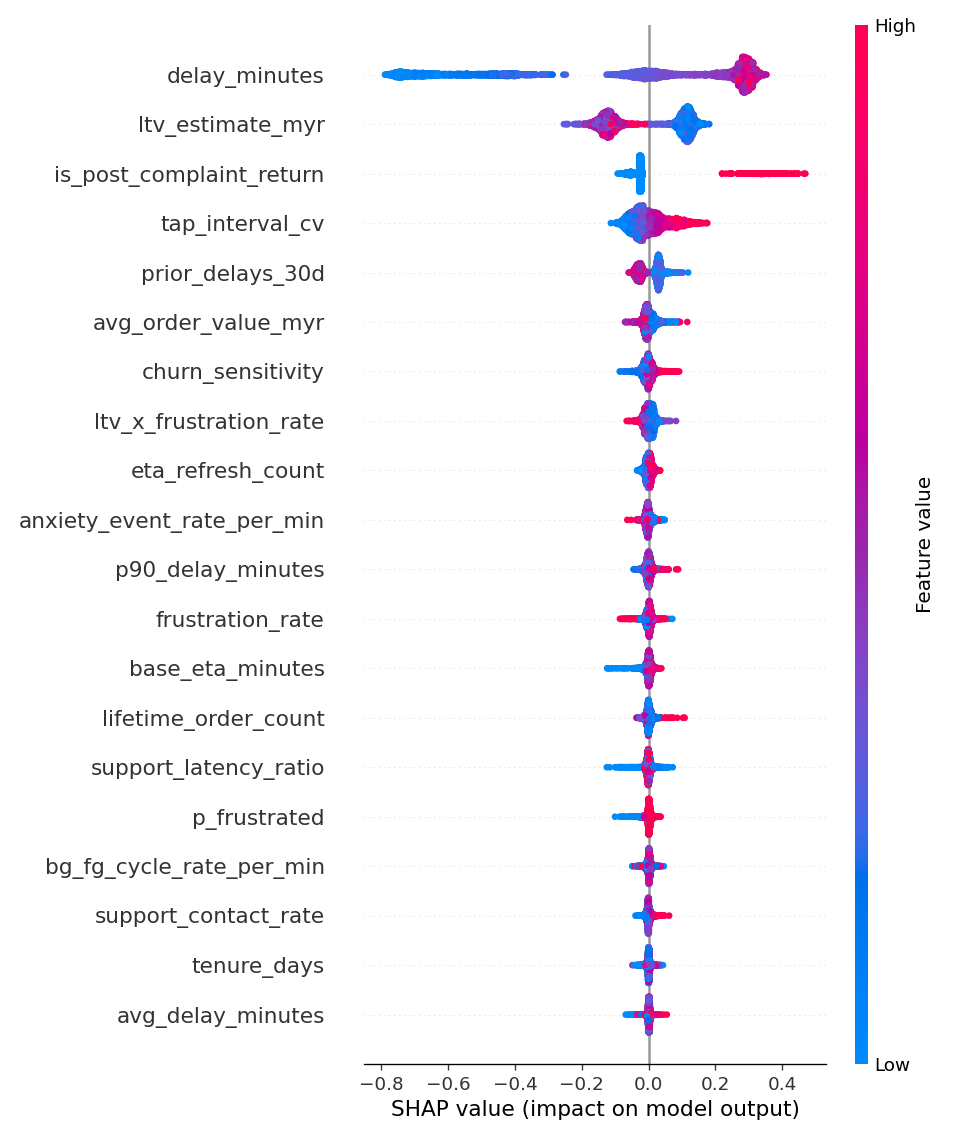

In [8]:
from IPython.display import Image, display
display(Image(filename=f"{FIGURES}/02_shap_beeswarm.png", width=700))


## 5. Two-Stage Architecture Flow

```
In-session events (Flink)
       |
       v
  SequenceFeaturizer       <- per-event (T, 9) feature matrix
       |
       v
  LSTM (hidden=64)          <- learns burst-pause tap_interval_cv pattern
       |
  p_frustrated score
       |
       v (if p_frustrated > 0.60)
  LightGBM churn head       <- P(churn | frustrated, user_profile)
  [tap_interval_cv is #4 SHAP feature here too]
       |
  combined_score = p_frustrated x p_churn
       |
       v
  DecisionEngine            <- LTV-gated tier selection
  [empathy / RM2 voucher / CS escalation]
```

The critical design property: `tap_interval_cv` is not just a model input —
it is the *same behavioural signal* that both stages rely on.
The LSTM learns it from sequences; LightGBM sees its session aggregate.


In [9]:
print("=" * 55)
print("TRAINING KEY NUMBERS")
print("=" * 55)
print(f"LSTM epochs trained        : {len(epochs)}")
print(f"LSTM ep-1 AUC              : {val_auc[0]:.4f}  (genuine learning)")
print(f"LSTM final val AUC         : {val_auc[-1]:.4f}  (sim artifact; target >0.88)")
print(f"LSTM val F1@0.5            : {final_metrics.get('val_f1', 'N/A'):.4f}")
print(f"LSTM train loss ep-1->15   : {train_loss[0]:.4f} -> {train_loss[-1]:.4f}")
print()
for label, key in seg_map.items():
    auc_val = final_metrics.get(key)
    if auc_val:
        print(f"  {label:30s}: {auc_val:.4f}")
print()
print(f"LightGBM val AUROC         : {lgbm_auroc:.4f}")
print(f"LightGBM avg precision     : {lgbm_ap:.4f}")
print(f"LightGBM churn label rate  : {churn_rate:.4f}")
print()
print("SHAP top features:")
for _, row in shap_df.head(5).iterrows():
    print(f"  {row['feature']:35s}: {row['mean_abs_shap']:.4f}")
print()
print("Figures saved to notebooks/figures/:")
for f in sorted(os.listdir("notebooks/figures")):
    if f.startswith("02_"):
        print(f"  {f}")


TRAINING KEY NUMBERS
LSTM epochs trained        : 15
LSTM ep-1 AUC              : 0.9054  (genuine learning)
LSTM final val AUC         : 0.9986  (sim artifact; target >0.88)
LSTM val F1@0.5            : 0.9841
LSTM train loss ep-1->15   : 0.8117 -> 0.0554

  Peak hours                    : 0.9987
  Rain                          : 0.9985
  Post-complaint return         : 0.9991

LightGBM val AUROC         : 0.6444
LightGBM avg precision     : 0.5027
LightGBM churn label rate  : 0.3882

SHAP top features:
  delay_minutes                      : 0.3029
  ltv_estimate_myr                   : 0.1181
  is_post_complaint_return           : 0.0588
  tap_interval_cv                    : 0.0400
  prior_delays_30d                   : 0.0301

Figures saved to notebooks/figures/:
  02_lstm_learning_curves.png
  02_lstm_segment_auc.png
  02_shap_beeswarm.png
  02_shap_importance_bar.png
